In [1]:
import sys
from pathlib import Path

_root = Path.cwd().resolve()
if not (_root / "src").is_dir():
    _root = _root.parent
sys.path.insert(0, str(_root))

import pandas as pd
import numpy as np
import arviz as az
import pickle
import matplotlib.pyplot as plt

from src.config import DATA_PROCESSED_DIR, POSTERIORS_DIR, FIGURES_DIR

Path(FIGURES_DIR).mkdir(parents=True, exist_ok=True)

df_test = pd.read_csv(Path(DATA_PROCESSED_DIR) / "markets_test.csv")
trace = az.from_netcdf(Path(POSTERIORS_DIR) / "hbrm_trace.nc")

with open(Path(POSTERIORS_DIR) / "baseline_predictions.pkl", "rb") as f:
    predictions = pickle.load(f)

categories = sorted(df_test["category_str"].unique().tolist())
cat_to_idx = {c: i for i, c in enumerate(categories)}
# Must match HBRM posterior axis (training had all categories; test rows use same cat_idx)
n_cats = int(trace.posterior["alpha"].shape[-1])
assert df_test["cat_idx"].max() < n_cats and df_test["cat_idx"].min() >= 0

In [2]:
# Extract from trace — shapes are (chains, draws, n_cats) for group params
alpha_samples = trace.posterior["alpha"].values
beta_samples = trace.posterior["beta"].values
gamma_vol_samples = trace.posterior["gamma_vol"].values
gamma_liq_samples = trace.posterior["gamma_liq"].values
gamma_spr_samples = trace.posterior["gamma_spr"].values

# Flatten chains × draws → (total_samples, ...)
alpha_flat = alpha_samples.reshape(-1, n_cats)
beta_flat = beta_samples.reshape(-1, n_cats)
gamma_vol_flat = gamma_vol_samples.reshape(-1)
gamma_liq_flat = gamma_liq_samples.reshape(-1)
gamma_spr_flat = gamma_spr_samples.reshape(-1)
n_posterior_samples = alpha_flat.shape[0]
print(f"Posterior samples available: {n_posterior_samples}")
print(f"Test observations: {len(df_test)}")

Posterior samples available: 8000
Test observations: 477


In [3]:
# Prepare test arrays
log_odds_test = df_test["log_odds"].values.astype(float)
cat_idx_test = df_test["cat_idx"].values.astype(int)
volume_z_test = df_test["volume_z"].values.astype(float)
liquidity_z_test = df_test["liquidity_z"].values.astype(float)
spread_z_test = df_test["spread_z"].values.astype(float)

# Matrix computation: (n_posterior_samples, n_test)
# For memory efficiency, use float32
alpha_flat = alpha_flat.astype(np.float32)
beta_flat = beta_flat.astype(np.float32)

logit_pred = (
      alpha_flat[:, cat_idx_test]
      + beta_flat[:, cat_idx_test] * log_odds_test[np.newaxis, :].astype(np.float32)
      + gamma_vol_flat[:, np.newaxis].astype(np.float32)
      * volume_z_test[np.newaxis, :].astype(np.float32)
      + gamma_liq_flat[:, np.newaxis].astype(np.float32)
      * liquidity_z_test[np.newaxis, :].astype(np.float32)
      + gamma_spr_flat[:, np.newaxis].astype(np.float32)
      * spread_z_test[np.newaxis, :].astype(np.float32)
  )

p_pred_samples = (1.0 / (1.0 + np.exp(-logit_pred))).astype(np.float32)  # sigmoid

# Point estimates and uncertainty
p_hbrm = p_pred_samples.mean(axis=0)
p_lower = np.percentile(p_pred_samples, 5, axis=0)
p_upper = np.percentile(p_pred_samples, 95, axis=0)
p_std = p_pred_samples.std(axis=0)

print(f"HBRM mean probability range: [{p_hbrm.min():.3f}, {p_hbrm.max():.3f}]")
print(f"Mean predictive uncertainty (std): {p_std.mean():.4f}")

HBRM mean probability range: [0.001, 0.961]
Mean predictive uncertainty (std): 0.0314


In [4]:
predictions["HBRM (Bayes)"] = p_hbrm
predictions["HBRM Lower 5%"] = p_lower
predictions["HBRM Upper 95%"] = p_upper

with open(Path(POSTERIORS_DIR) / "all_predictions.pkl", "wb") as f:
    pickle.dump(predictions, f)
print("All predictions saved to outputs/posteriors/all_predictions.pkl")

All predictions saved to outputs/posteriors/all_predictions.pkl


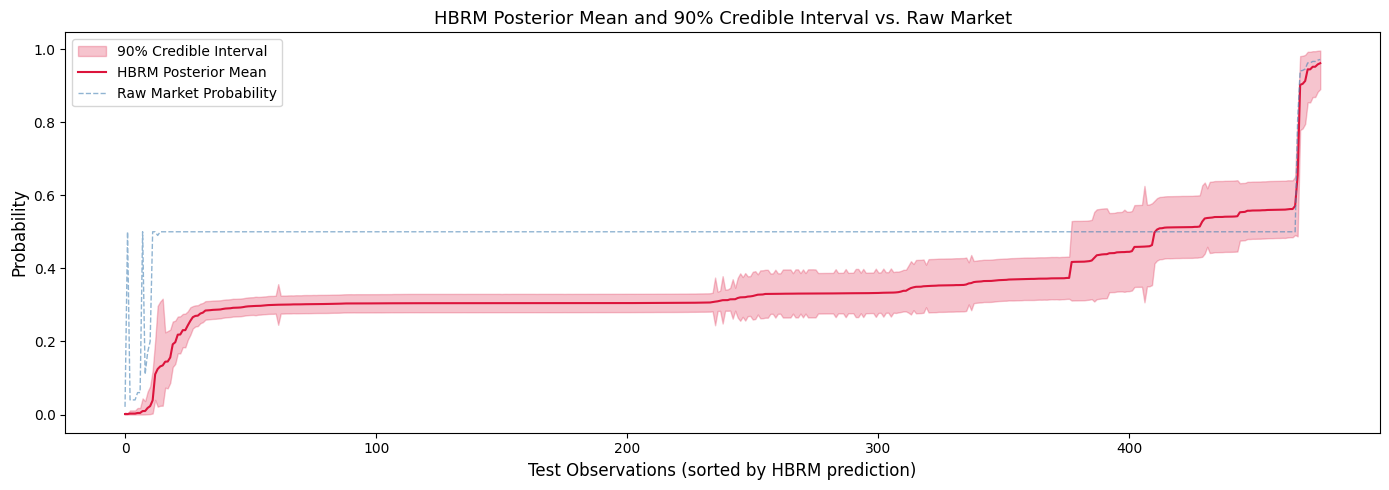

In [5]:
# Sort by predicted probability for clean visualization
sort_idx = np.argsort(p_hbrm)
x_vals = np.arange(len(sort_idx))

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(
    x_vals,
    p_lower[sort_idx],
    p_upper[sort_idx],
    alpha=0.25,
    color="crimson",
    label="90% Credible Interval",
)
ax.plot(
    x_vals,
    p_hbrm[sort_idx],
    color="crimson",
    lw=1.5,
    label="HBRM Posterior Mean",
)
ax.plot(
    x_vals,
    predictions["Raw Market"][sort_idx],
    color="steelblue",
    lw=1.0,
    alpha=0.6,
    linestyle="--",
    label="Raw Market Probability",
)
ax.set_xlabel("Test Observations (sorted by HBRM prediction)", fontsize=12)
ax.set_ylabel("Probability", fontsize=12)
ax.set_title(
    "HBRM Posterior Mean and 90% Credible Interval vs. Raw Market", fontsize=13
)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(Path(FIGURES_DIR) / "11_posterior_uncertainty.png", dpi=200, bbox_inches="tight")
plt.show()

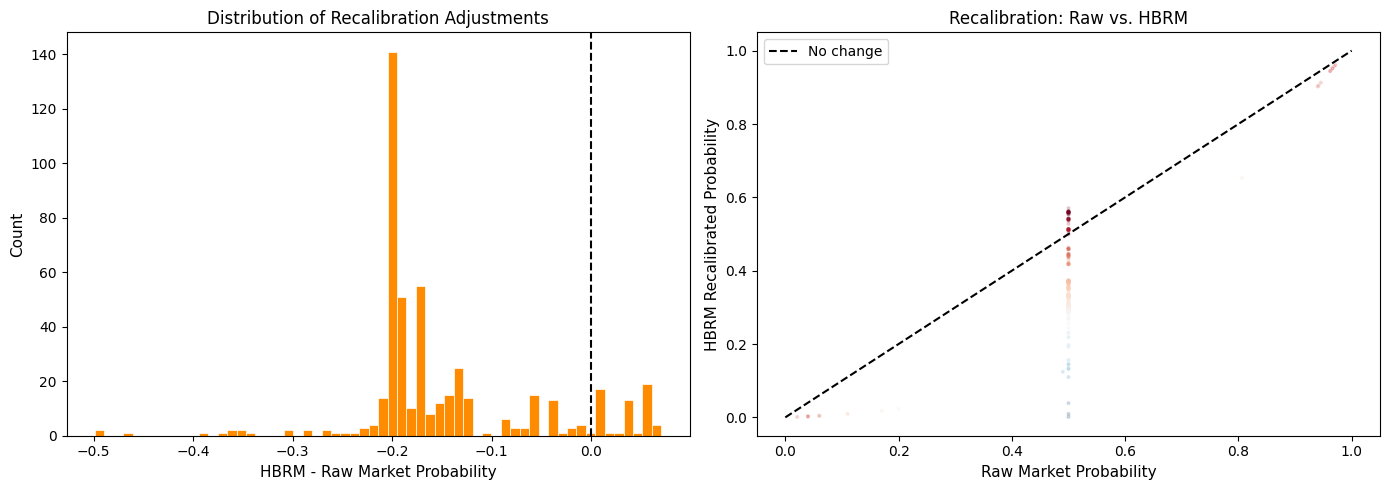

In [6]:
delta = p_hbrm - predictions["Raw Market"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(delta, bins=60, color="darkorange", edgecolor="white", linewidth=0.5)
axes[0].axvline(0, color="black", linestyle="--", lw=1.5)
axes[0].set_xlabel("HBRM - Raw Market Probability", fontsize=11)
axes[0].set_ylabel("Count", fontsize=11)
axes[0].set_title("Distribution of Recalibration Adjustments", fontsize=12)

axes[1].scatter(
    predictions["Raw Market"],
    p_hbrm,
    alpha=0.15,
    s=4,
    c=delta,
    cmap="RdBu_r",
)
axes[1].plot([0, 1], [0, 1], "k--", lw=1.5, label="No change")
axes[1].set_xlabel("Raw Market Probability", fontsize=11)
axes[1].set_ylabel("HBRM Recalibrated Probability", fontsize=11)
axes[1].set_title("Recalibration: Raw vs. HBRM", fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.savefig(Path(FIGURES_DIR) / "12_recalibration_shift.png", dpi=200, bbox_inches="tight")
plt.show()